# Pakistan Suicide Attacks Analysis (1995–2017)

This notebook analyzes the frequency, fatalities, locations, and timing patterns of suicide attacks in Pakistan using exploratory data analysis and visualizations.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
df = pd.read_csv("PakistanSuicideAttacks_Cleaned (1).csv")
df["Date"] = pd.to_datetime(df["Date"],format = "mixed")
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(0)

## 1. Attack Frequency Vs Fatalities
Does increase in attacks also increase fatalities. The Chart Showcases the relationship between attacks and fatalities

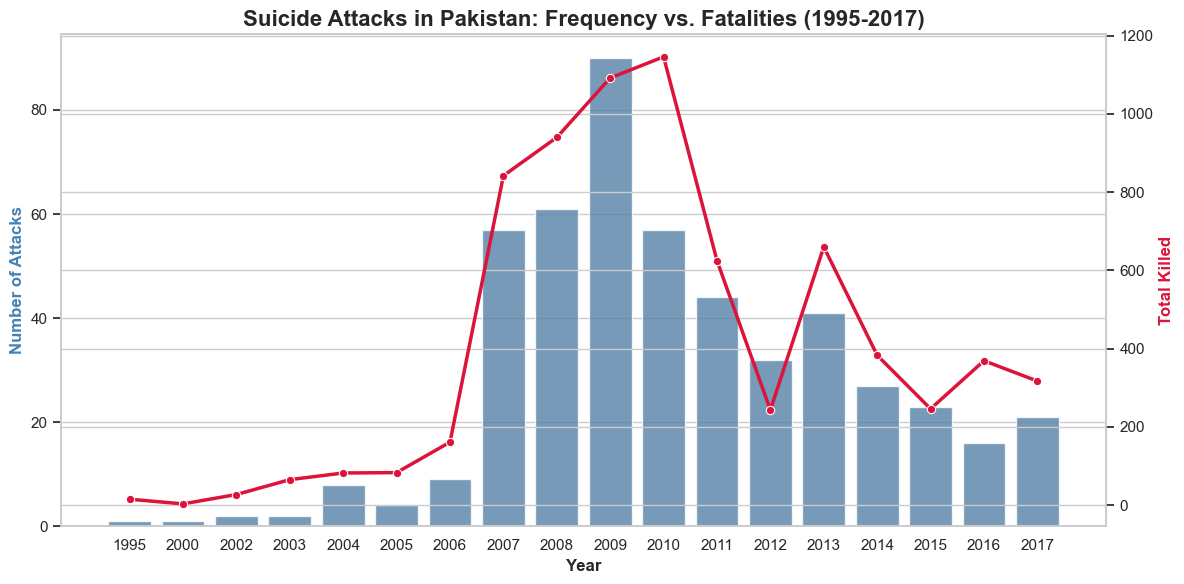

Pearson r = 0.95, p-value = 0.0000


In [19]:
yearly_stats = df.groupby(df["Date"].dt.year).agg(
    Total_attacks = ("S#","count"),
    Total_Killed = ("Killed Max","sum")
).reset_index()

yearly_stats.rename(columns={'Date': 'Year'}, inplace=True)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))


sns.barplot(data=yearly_stats, x='Year', y='Total_attacks', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_ylabel('Number of Attacks', color='steelblue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(data=yearly_stats, x=yearly_stats.index, y='Total_Killed', color='crimson', marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('Total Killed', color='crimson', fontsize=12, fontweight='bold')

plt.title('Suicide Attacks in Pakistan: Frequency vs. Fatalities (1995-2017)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
r, p = pearsonr(yearly_stats['Total_attacks'], yearly_stats['Total_Killed'])
print(f"Pearson r = {r:.2f}, p-value = {p:.4f}")

**Insight:** Attack frequency and fatalities rise together, peaking around 2009–2013. The Pearson correlation confirms a strong positive relationship — years with more attacks consistently record higher death tolls. 2009 stands out as the single deadliest year.

## 2. Top 5 Deadliest Cities
Which cities have the highest fatilites over the period of 1995-2017

C:\Users\Taha\AppData\Local\Temp\ipykernel_7136\2219951326.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_5cities, x = "City",y = "Total_Killed",palette = "Reds_r")


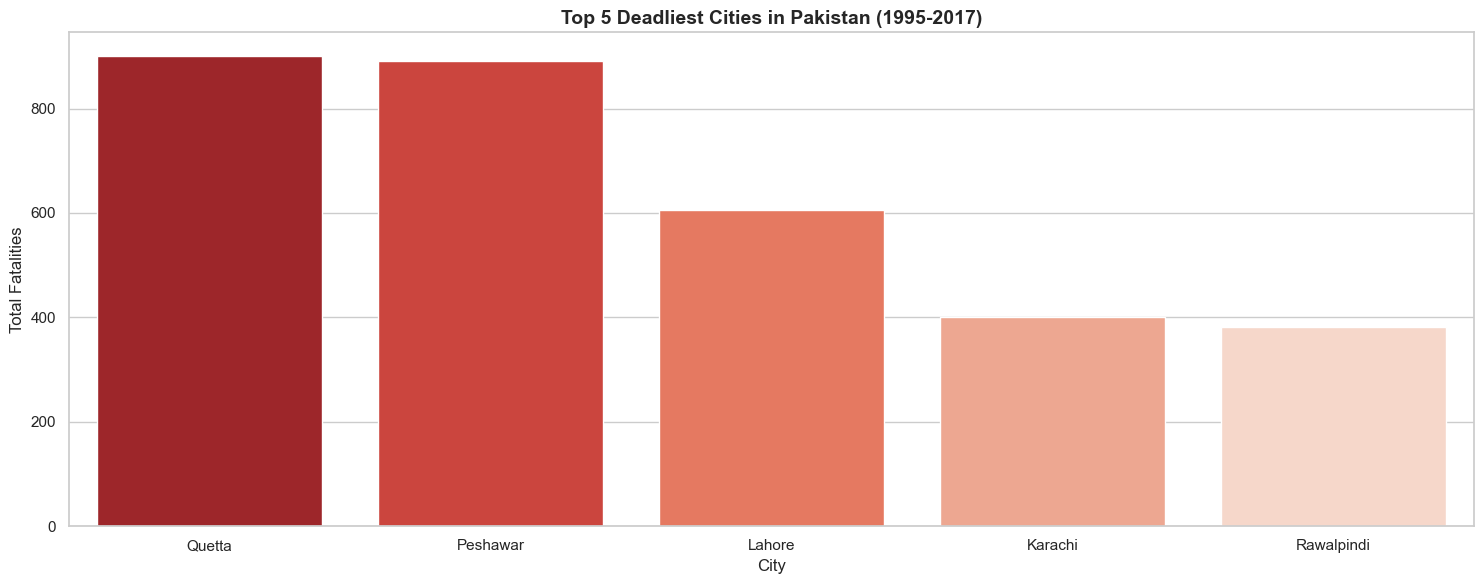

In [20]:
deadliest_cities = df.groupby("City").agg(
    Total_Killed = ("Killed Max", "sum")
)
top_5cities = deadliest_cities.sort_values(by = "Total_Killed",ascending= False).head(5)


plt.figure(figsize = (15,6))
sns.barplot(data = top_5cities, x = "City",y = "Total_Killed",palette = "Reds_r")
plt.title('Top 5 Deadliest Cities in Pakistan (1995-2017)', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Fatalities', fontsize=12)

plt.tight_layout()
plt.show()

### Key Metric Insight: The Population Disparity
While megacities like Karachi and Lahore have massive, dense populations (exceeding 10-15 million people), the data reveals that **Quetta** and **Peshawar** are the deadliest cities by a significant margin. The fact that Quetta—a city with a substantially lower population—bears the highest fatality toll is a stark and tragic finding. This indicates a hyper-concentration of severe, high-yield attacks targeting critical zones in these specific regional capitals, causing a disproportionately devastating impact on smaller urban populations.

## 3. Deadliest location categories

Which location types accumulated the most fatalities across all attacks?

C:\Users\Taha\AppData\Local\Temp\ipykernel_7136\3404320397.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= deadliest_location, x="Location Category", y="Total_killed", palette="Reds_r")


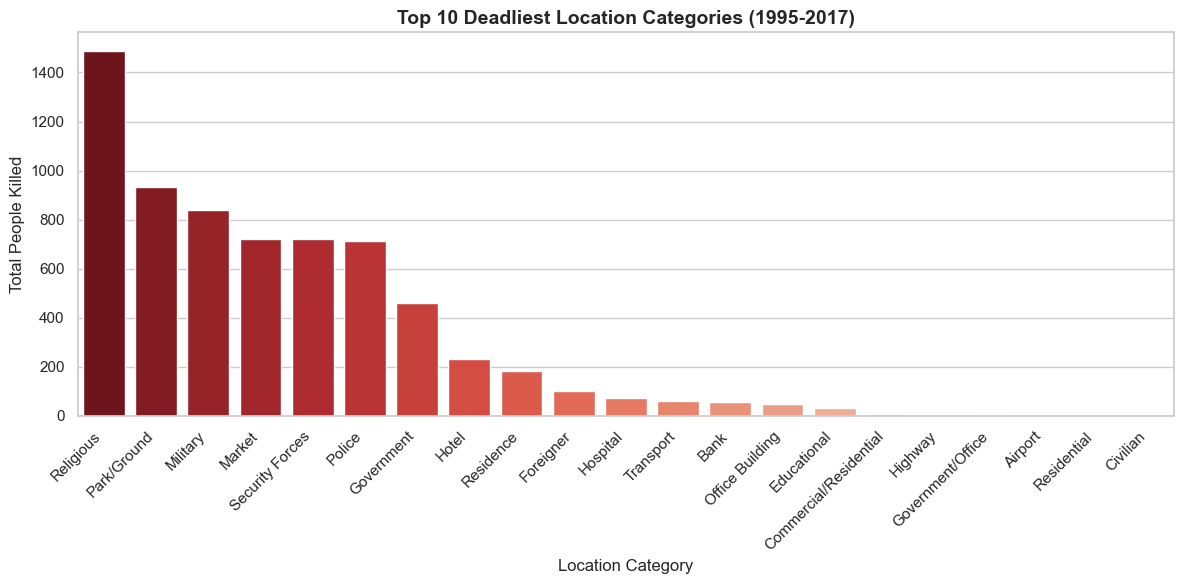

In [21]:
deadliest_location = df.groupby("Location Category").agg(
    Total_killed  = ("Killed Max","sum")
).reset_index()
deadliest_location = deadliest_location.sort_values(by ="Total_killed",ascending= False)
plt.figure(figsize=(12, 6))
sns.barplot(data= deadliest_location, x="Location Category", y="Total_killed", palette="Reds_r")
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Deadliest Location Categories (1995-2017)', fontsize=14, fontweight='bold')
plt.xlabel('Location Category', fontsize=12)
plt.ylabel('Total People Killed', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** Although security forces are the most frequently targeted, soft targets such as religious institutions, markets, and parks account for a disproportionately high share of fatalities — likely because these locations offer no armed resistance and draw large civilian crowds.

## 4. Open vs closed spaces

Does the physical environment of an attack affect how lethal it is on average?

C:\Users\Taha\AppData\Local\Temp\ipykernel_7136\3754421134.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=space_stats, x='Open/Closed Space', y='Avg_Killed', palette='viridis')


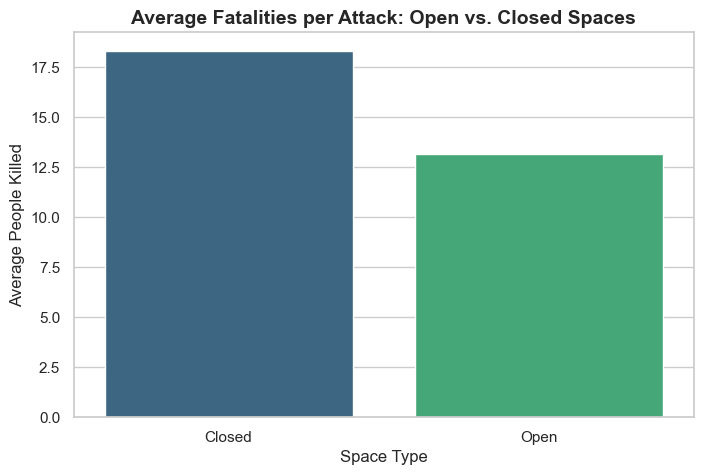

In [22]:
space_df = df[df['Open/Closed Space'].isin(['Open', 'Closed'])]
space_stats = space_df.groupby('Open/Closed Space').agg(
    Avg_Killed = ("Killed Max","mean")
)
plt.figure(figsize=(8, 5))
sns.barplot(data=space_stats, x='Open/Closed Space', y='Avg_Killed', palette='viridis')
plt.title('Average Fatalities per Attack: Open vs. Closed Spaces', fontsize=14, fontweight='bold')
plt.ylabel('Average People Killed', fontsize=12)
plt.xlabel('Space Type', fontsize=12)
plt.show()

**Insight:** Closed spaces produce a higher average fatality count per attack. Enclosed environments concentrate the blast effect and limit escape routes, making them more lethal even when the number of attackers or explosive quantity is similar.

## 5. Blast Day Type:

Does the Day of an attack affect how lethal it is on average?

C:\Users\Taha\AppData\Local\Temp\ipykernel_7136\1074226570.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Day_stats, x='Blast Day Type', y='Avg_Killed', palette='viridis')


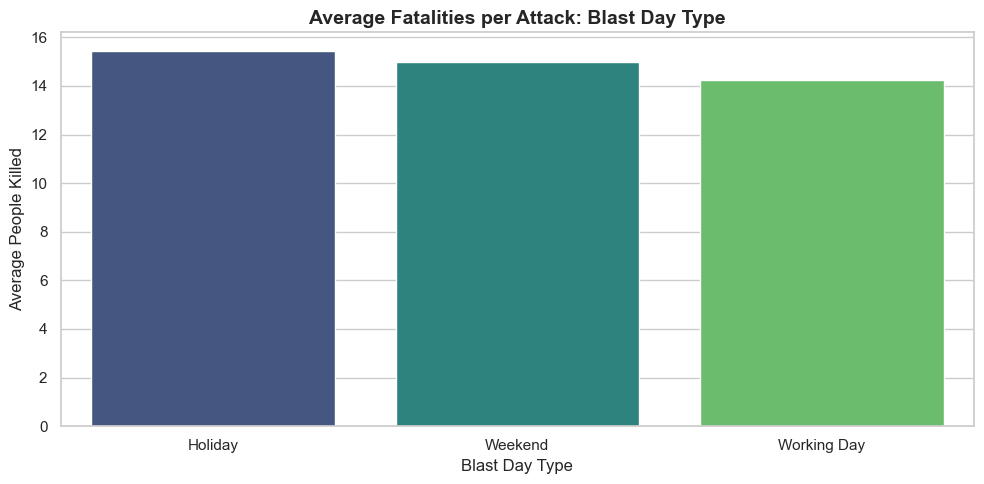

In [23]:
Day_stats = df.groupby('Blast Day Type').agg(
    Avg_Killed=("Killed Max", "mean")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=Day_stats, x='Blast Day Type', y='Avg_Killed', palette='viridis')
plt.title('Average Fatalities per Attack: Blast Day Type', fontsize=14, fontweight='bold')
plt.ylabel('Average People Killed', fontsize=12)
plt.xlabel('Blast Day Type', fontsize=12)
plt.tight_layout()
plt.show()


**Insight:** While the absolute frequency of attacks is heavily concentrated on Working Days, this visualization reveals that attacks executed on Holidays and Weekends actually yield a higher average fatality rate. This indicates that while less frequent, holiday attacks are potentially more devastating as they likely target larger civilian or religious gatherings.


## 6. Fatality Estimate Range: Killed Min vs Killed Max

How wide is the uncertainty in the total death toll across all attacks?

C:\Users\Taha\AppData\Local\Temp\ipykernel_7136\867525697.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=summary, x='Estimate', y='Total Killed', palette=['#66b3ff', '#ff6b6b'])


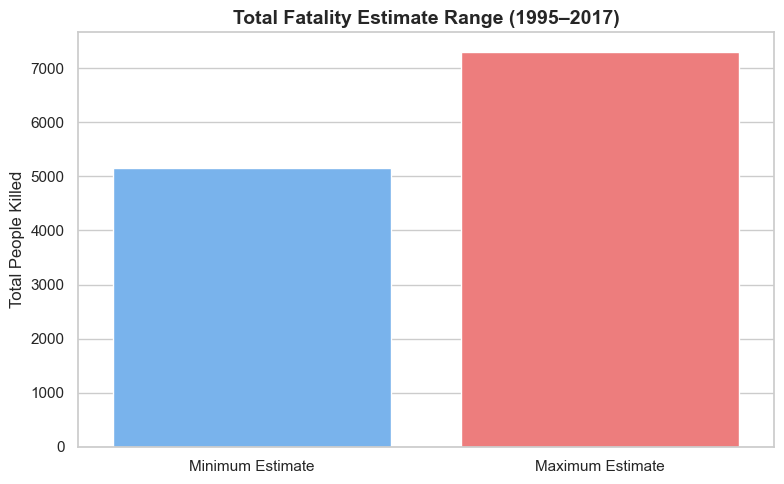

Uncertainty range: 2,145 lives


In [24]:

summary = pd.DataFrame({
    'Estimate': ['Minimum Estimate', 'Maximum Estimate'],
    'Total Killed': [df['Killed Min'].sum(), df['Killed Max'].sum()]
})

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=summary, x='Estimate', y='Total Killed', palette=['#66b3ff', '#ff6b6b'])


plt.title('Total Fatality Estimate Range (1995–2017)', fontsize=14, fontweight='bold')
plt.ylabel('Total People Killed', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()

uncertainty = df['Killed Max'].sum() - df['Killed Min'].sum()
print(f"Uncertainty range: {int(uncertainty):,} lives")

**Insight:**The gap between the minimum and maximum estimates reveals the scale of reporting uncertainty in conflict data. The difference of potentially thousands of lives highlights how difficult it is to establish ground truth in active conflict zones — a critical caveat for any policy conclusions drawn from this analysis.


## Final Project Conclusion & Strategic Insights

This exploratory data analysis reveals several critical insights into the patterns and impact of suicide attacks in Pakistan from 1995 to 2017:

1. **Historical Escalation & Peak:** The timeline demonstrates a massive escalation in attacks beginning in 2007. Incident frequency peaked in 2009 (90 attacks), while the total human cost peaked the following year in 2010 (1,146 fatalities). 
2. **The Target-Severity Paradox:** While security forces (Police and Military) are the most frequent targets of these attacks, the highest casualty counts consistently occur in softer, civilian-heavy locations such as Parks, Religious sites, and Commercial areas. 
3. **Situational and Environmental Risks:** Attackers show a clear strategic preference for Working Days, which account for over 80% of all incidents. However, attacks executed on Holidays and within Closed (indoor) spaces yield a significantly higher average fatality rate per incident. This is likely driven by the targeting of denser crowds and the deadly physics of blast containment indoors.
4. **Data Uncertainty:** The gap between the minimum and maximum estimates reveals the scale of reporting uncertainty in conflict data. The difference of potentially thousands of lives highlights how difficult it is to establish ground truth in active conflict zones — a critical caveat for any policy conclusions drawn from this analysis.

**Actionable Takeaway:** For threat assessment and policy planning, this analysis highlights a critical divergence: while everyday security infrastructure must focus on protecting law enforcement assets on working days, emergency medical response and crowd-control resources must be heavily prioritized for civilian and religious gatherings during holidays, where the human cost per incident is statistically at its highest.